# EDA clientes

In [1]:
# Importar librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
sns.set_theme(style="whitegrid")

In [2]:
import os
from pathlib import Path

# Configuración de ruta de datos (dinámica y sobreescribible vía variable de entorno DATA_DIR)
DATA_DIR = Path(os.getenv("DATA_DIR", "../Data")).resolve()

# Cargar dataset
clientes = pd.read_csv(DATA_DIR / "dataset_clientes.csv")

In [3]:
# Ver dimensiones del dataset
clientes.shape

(100000, 24)

In [4]:
# Ver primeras filas del dataset
clientes.head()

,cliente_id,tipo_cliente,antiguedad_meses,tiene_movil,tiene_hogar,oferta_hogar_id,tiene_internet_hogar,es_movistar_total,elegible_mt,plan_actual_id,monto_facturado_prom,edad_rango,ubicacion_departamento,es_usuario_app,consumo_datos_gb_prom,consumo_voz_min_prom,consumo_sms_prom,uso_app_movistar_prom,monto_facturado_prom_6m,dias_mora_prom,meses_moroso,n_reclamos,n_actividad_canal,canal_mas_usado
0,CLI000001,postpago,17,True,False,NaN,False,False,False,OF002,58.39,56-65,Junin,True,20.103333,200.000000,8.166667,3.333333,58.251667,24.833333,3,0,7,Call In
1,CLI000002,NaN,140,False,True,OF009,True,False,False,OF009,111.41,26-35,Cusco,True,2.598333,219.000000,8.500000,2.500000,112.186667,18.000000,2,0,3,Digital
2,CLI000003,postpago,118,True,True,OF007,False,False,False,OF004,100.71,36-45,Arequipa,False,64.243333,149.166667,8.500000,0.000000,99.630000,1.166667,0,1,3,Tienda
3,CLI000004,prepago,79,True,False,NaN,False,False,False,OF003,70.44,18-25,La Libertad,True,30.841667,183.166667,5.833333,2.000000,71.758333,15.333333,2,0,6,Call In
4,CLI000005,prepago,78,True,False,NaN,False,False,False,OF003,76.87,36-45,Lambayeque,True,37.773333,271.833333,5.166667,2.166667,77.006667,17.333333,2,0,1,Digital


## 1. Nulos originales

In [5]:
# Revisar nulos originales
clientes.isna().sum().to_frame("nulos").assign(
    pct=lambda x: (x["nulos"] / len(clientes) * 100).round(2)
).query("nulos > 0")

,nulos,pct
tipo_cliente,6734,6.73
oferta_hogar_id,54758,54.76
canal_mas_usado,961,0.96


-Los nulos de  `tipo_cliente` se explican por clientes que no tienen linea movil.

-Los nulos de `oferta_hogar_id` se explican por clientes sin servicio hogar.

-Los nulos de `canal_mas_usado` corresponden a clientes sin actividad registrada en canales.

## 2. Recodificacion de nulos estructurales

In [6]:
# Estandarizar texto a minusculas y quitar espacios
ids = ["cliente_id", "oferta_hogar_id", "plan_actual_id"]

for col in clientes.select_dtypes(include="object").columns:
    if col not in ids:
        clientes[col] = clientes[col].str.strip().str.lower()

In [7]:
# Recodificacion de nulos estructurales
reporte_nulos = []

mask = clientes["oferta_hogar_id"].isna()
cond = clientes["tiene_hogar"] == False
clientes.loc[mask & cond, "oferta_hogar_id"] = "sin_servicio_hogar"
reporte_nulos.append(["oferta_hogar_id", mask.sum(), "tiene_hogar = False", "sin_servicio_hogar", (mask & cond).sum(), (mask & ~cond).sum()])

mask = clientes["tipo_cliente"].isna()
cond = clientes["tiene_movil"] == False
clientes.loc[mask & cond, "tipo_cliente"] = "sin_movil"
reporte_nulos.append(["tipo_cliente", mask.sum(), "tiene_movil = False", "sin_movil", (mask & cond).sum(), (mask & ~cond).sum()])

mask = clientes["canal_mas_usado"].isna()
cond = clientes["n_actividad_canal"] == 0
clientes.loc[mask & cond, "canal_mas_usado"] = "sin_actividad"
reporte_nulos.append(["canal_mas_usado", mask.sum(), "n_actividad_canal = 0", "sin_actividad", (mask & cond).sum(), (mask & ~cond).sum()])

reporte_nulos = pd.DataFrame(reporte_nulos, columns=[
    "columna", "nulos_originales", "regla_usada", "categoria_creada",
    "cantidad_recodificada", "nulos_problematicos_restantes"
])
reporte_nulos

,columna,nulos_originales,regla_usada,categoria_creada,cantidad_recodificada,nulos_problematicos_restantes
0,oferta_hogar_id,54758,tiene_hogar = False,sin_servicio_hogar,54758,0
1,tipo_cliente,6734,tiene_movil = False,sin_movil,6734,0
2,canal_mas_usado,961,n_actividad_canal = 0,sin_actividad,961,0


**Hallazgo:** los nulos estructurales quedaron como categorias explicitas. No se uso media, mediana ni moda.

## 3. Conversion de variables ordinales

Algunas columnas vienen como numeros, pero conceptualmente son conteos o escalas ordinales. Para no confundirlas con variables numericas continuas, se tratan como categorias ordenadas en el EDA.

In [8]:
# Convertir variables de conteo/ordinales a categorias ordenadas
vars_ordinales = ["meses_moroso", "n_reclamos", "n_actividad_canal"]

for col in vars_ordinales:
    categorias = sorted(clientes[col].dropna().unique())
    clientes[col] = pd.Categorical(clientes[col], categories=categorias, ordered=True)

**Hallazgo:** `meses_moroso`, `n_reclamos` y `n_actividad_canal` son conteos ordenados. Por eso no se analizan como variables continuas ni se usan para detectar outliers con IQR.

## 4. Estadisticos generales de clientes

In [9]:
# Estadisticos generales del dataset completo
clientes.describe(include="all")

,cliente_id,tipo_cliente,antiguedad_meses,tiene_movil,tiene_hogar,oferta_hogar_id,tiene_internet_hogar,es_movistar_total,elegible_mt,plan_actual_id,monto_facturado_prom,edad_rango,ubicacion_departamento,es_usuario_app,consumo_datos_gb_prom,consumo_voz_min_prom,consumo_sms_prom,uso_app_movistar_prom,monto_facturado_prom_6m,dias_mora_prom,meses_moroso,n_reclamos,n_actividad_canal,canal_mas_usado
count,100000,100000,100000.00000,100000,100000,100000,100000,100000,100000,100000,100000.000000,100000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.0,100000.0,100000
unique,100000,3,NaN,2,2,7,2,2,2,13,NaN,6,9,2,NaN,NaN,NaN,NaN,NaN,NaN,7.0,4.0,22.0,5
top,CLI000001,postpago,NaN,True,False,sin_servicio_hogar,False,False,False,OF003,NaN,26-35,lima,True,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,5.0,digital
freq,1,55858,NaN,93266,54758,54758,59214,92806,86350,21794,NaN,28045,45009,75119,NaN,NaN,NaN,NaN,NaN,NaN,36105.0,81627.0,15057.0,38907
mean,NaN,NaN,90.47525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.198674,NaN,NaN,NaN,29.681586,180.874783,7.998790,2.254005,81.198052,7.976647,NaN,NaN,NaN,NaN
std,NaN,NaN,51.95250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.226914,NaN,NaN,NaN,19.950078,35.937516,1.149806,1.434304,40.248681,7.392031,NaN,NaN,NaN,NaN
min,NaN,NaN,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.300000,NaN,NaN,NaN,0.686667,45.166667,3.500000,0.000000,27.610000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,45.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.200000,NaN,NaN,NaN,10.115000,156.333333,7.166667,1.166667,55.138333,1.333333,NaN,NaN,NaN,NaN
50%,NaN,NaN,91.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.380000,NaN,NaN,NaN,23.615000,180.666667,8.000000,2.666667,76.311667,6.833333,NaN,NaN,NaN,NaN
75%,NaN,NaN,135.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.150000,NaN,NaN,NaN,44.728333,205.166667,8.833333,3.333333,97.137083,12.166667,NaN,NaN,NaN,NaN


**Hallazgo:** esta tabla resume el dataset completo. Para variables numericas muestra media, desviacion, minimos, maximos y cuartiles. Para variables categoricas muestra cantidad, categoria mas frecuente y frecuencia.

In [10]:
# Estadisticos generales solo de variables categoricas y ordinales
clientes.describe(include=["object", "bool", "category"])

,cliente_id,tipo_cliente,tiene_movil,tiene_hogar,oferta_hogar_id,tiene_internet_hogar,es_movistar_total,elegible_mt,plan_actual_id,edad_rango,ubicacion_departamento,es_usuario_app,meses_moroso,n_reclamos,n_actividad_canal,canal_mas_usado
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,100000,3,2,2,7,2,2,2,13,6,9,2,7,4,22,5
top,CLI000001,postpago,True,False,sin_servicio_hogar,False,False,False,OF003,26-35,lima,True,1,0,5,digital
freq,1,55858,93266,54758,54758,59214,92806,86350,21794,28045,45009,75119,36105,81627,15057,38907


**Hallazgo categoricas:** para variables categoricas y ordinales, los estadisticos principales son `count`, `unique`, `top` y `freq`. `top` funciona como la moda, es decir, la categoria mas frecuente.

## 5. Distribucion general de variables numericas

Se grafican varias variables numericas en conjunto para ver forma, concentracion, sesgo y posibles colas largas.

In [11]:
# Seleccionar solo variables numericas continuas para graficos y outliers
vars_numericas = [
    "antiguedad_meses",
    "monto_facturado_prom",
    "consumo_datos_gb_prom",
    "consumo_voz_min_prom",
    "consumo_sms_prom",
    "uso_app_movistar_prom",
    "monto_facturado_prom_6m",
    "dias_mora_prom"
]

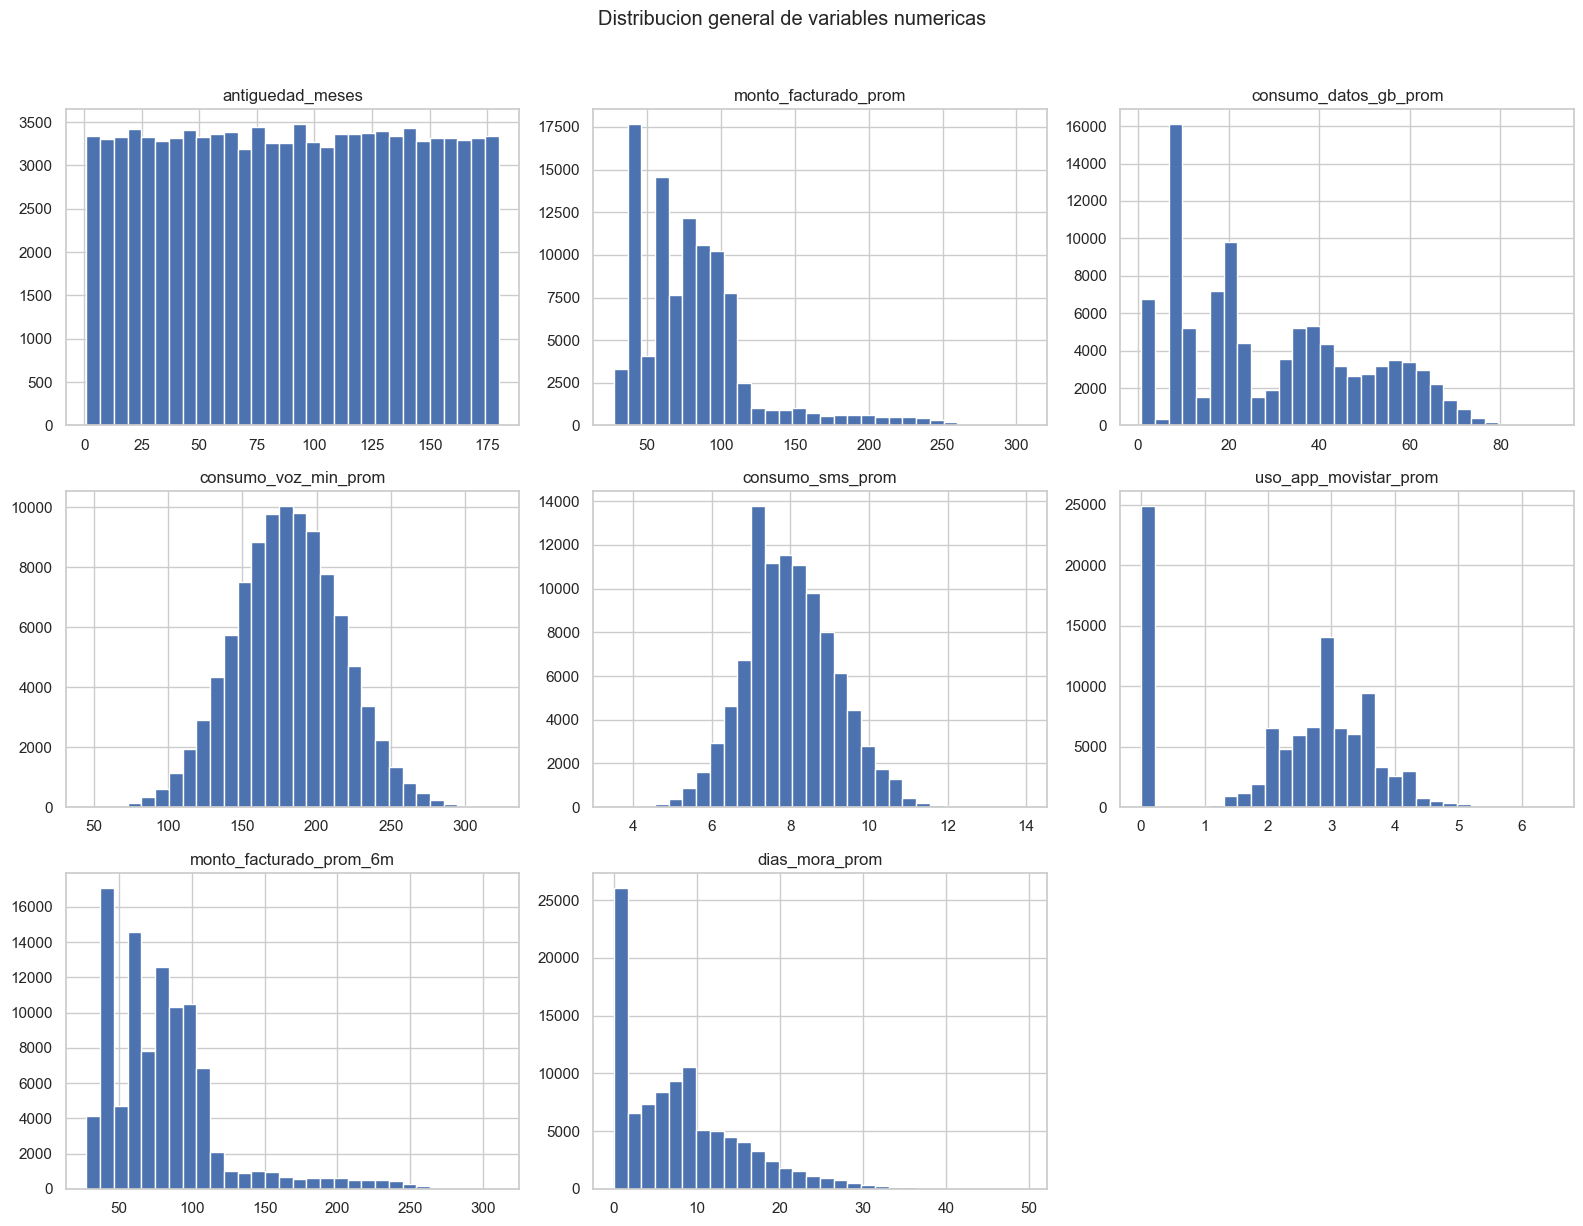

In [12]:
# Graficar distribuciones generales de variables numericas
clientes[vars_numericas].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribucion general de variables numericas", y=1.02)
plt.tight_layout()
plt.show()

**Hallazgo:** las distribuciones muestran que no todas las variables tienen forma simetrica. Algunas pueden estar concentradas en pocos valores o tener colas largas, lo cual sera importante para preprocesamiento posterior.

## 6. Revision general de outliers

Se usan boxplots para ver valores extremos de forma visual. No se elimina nada en el EDA.

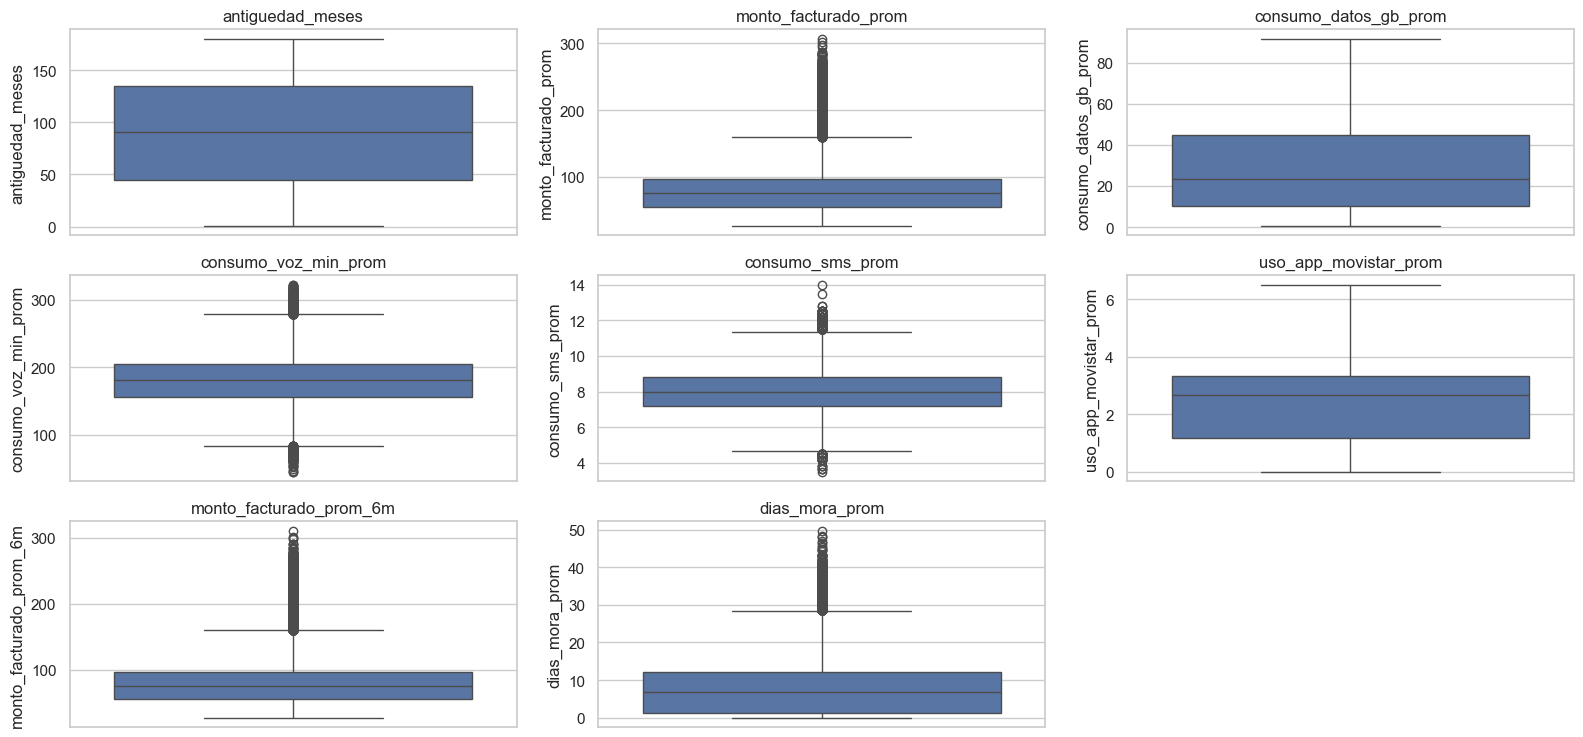

In [13]:
# Graficar boxplots generales para detectar outliers
plt.figure(figsize=(16, 10))
for i, col in enumerate(vars_numericas, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=clientes[col])
    plt.title(col)
plt.tight_layout()
plt.show()

**Hallazgo:** los boxplots permiten ver posibles outliers en variables de facturacion, consumo, mora, reclamos y actividad. Estos valores pueden representar clientes atipicos, pero no necesariamente errores.

In [14]:
# Resumen general de outliers con regla IQR
outliers = []

for col in vars_numericas:
    q1 = clientes[col].quantile(0.25)
    q3 = clientes[col].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    n_outliers = ((clientes[col] < limite_inf) | (clientes[col] > limite_sup)).sum()
    pct_outliers = n_outliers / len(clientes) * 100
    outliers.append([col, q1, q3, iqr, limite_inf, limite_sup, n_outliers, pct_outliers])

outliers = pd.DataFrame(outliers, columns=[
    "variable", "q1", "q3", "iqr", "limite_inf", "limite_sup", "n_outliers", "pct_outliers"
])

outliers.sort_values("pct_outliers", ascending=False)

,variable,q1,q3,iqr,limite_inf,limite_sup,n_outliers,pct_outliers
1,monto_facturado_prom,55.200000,97.150000,41.950000,-7.725000,160.075000,5469,5.469
6,monto_facturado_prom_6m,55.138333,97.137083,41.998750,-7.859792,160.135208,5463,5.463
7,dias_mora_prom,1.333333,12.166667,10.833333,-14.916667,28.416667,1429,1.429
3,consumo_voz_min_prom,156.333333,205.166667,48.833333,83.083333,278.416667,621,0.621
4,consumo_sms_prom,7.166667,8.833333,1.666667,4.666667,11.333333,317,0.317
0,antiguedad_meses,45.000000,135.000000,90.000000,-90.000000,270.000000,0,0.000
2,consumo_datos_gb_prom,10.115000,44.728333,34.613333,-41.805000,96.648333,0,0.000
5,uso_app_movistar_prom,1.166667,3.333333,2.166667,-2.083333,6.583333,0,0.000


**Hallazgo:** esta tabla no reemplaza el grafico; solo resume que variables tienen mas valores extremos. La decision de tratarlos queda para preprocesamiento, no para este EDA.

## 7. Distribucion general de variables categoricas y ordinales

Se grafican las variables categoricas principales en conjunto. No se muestran tablas de conteo por separado.

In [15]:
# Seleccionar variables categoricas y ordinales principales para graficos generales
vars_categoricas = [
    "tipo_cliente",
    "edad_rango",
    "ubicacion_departamento",
    "canal_mas_usado",
    "tiene_movil",
    "tiene_hogar",
    "tiene_internet_hogar",
    "es_movistar_total",
    "elegible_mt",
    "es_usuario_app",
    "meses_moroso",
    "n_reclamos",
    "n_actividad_canal"
]

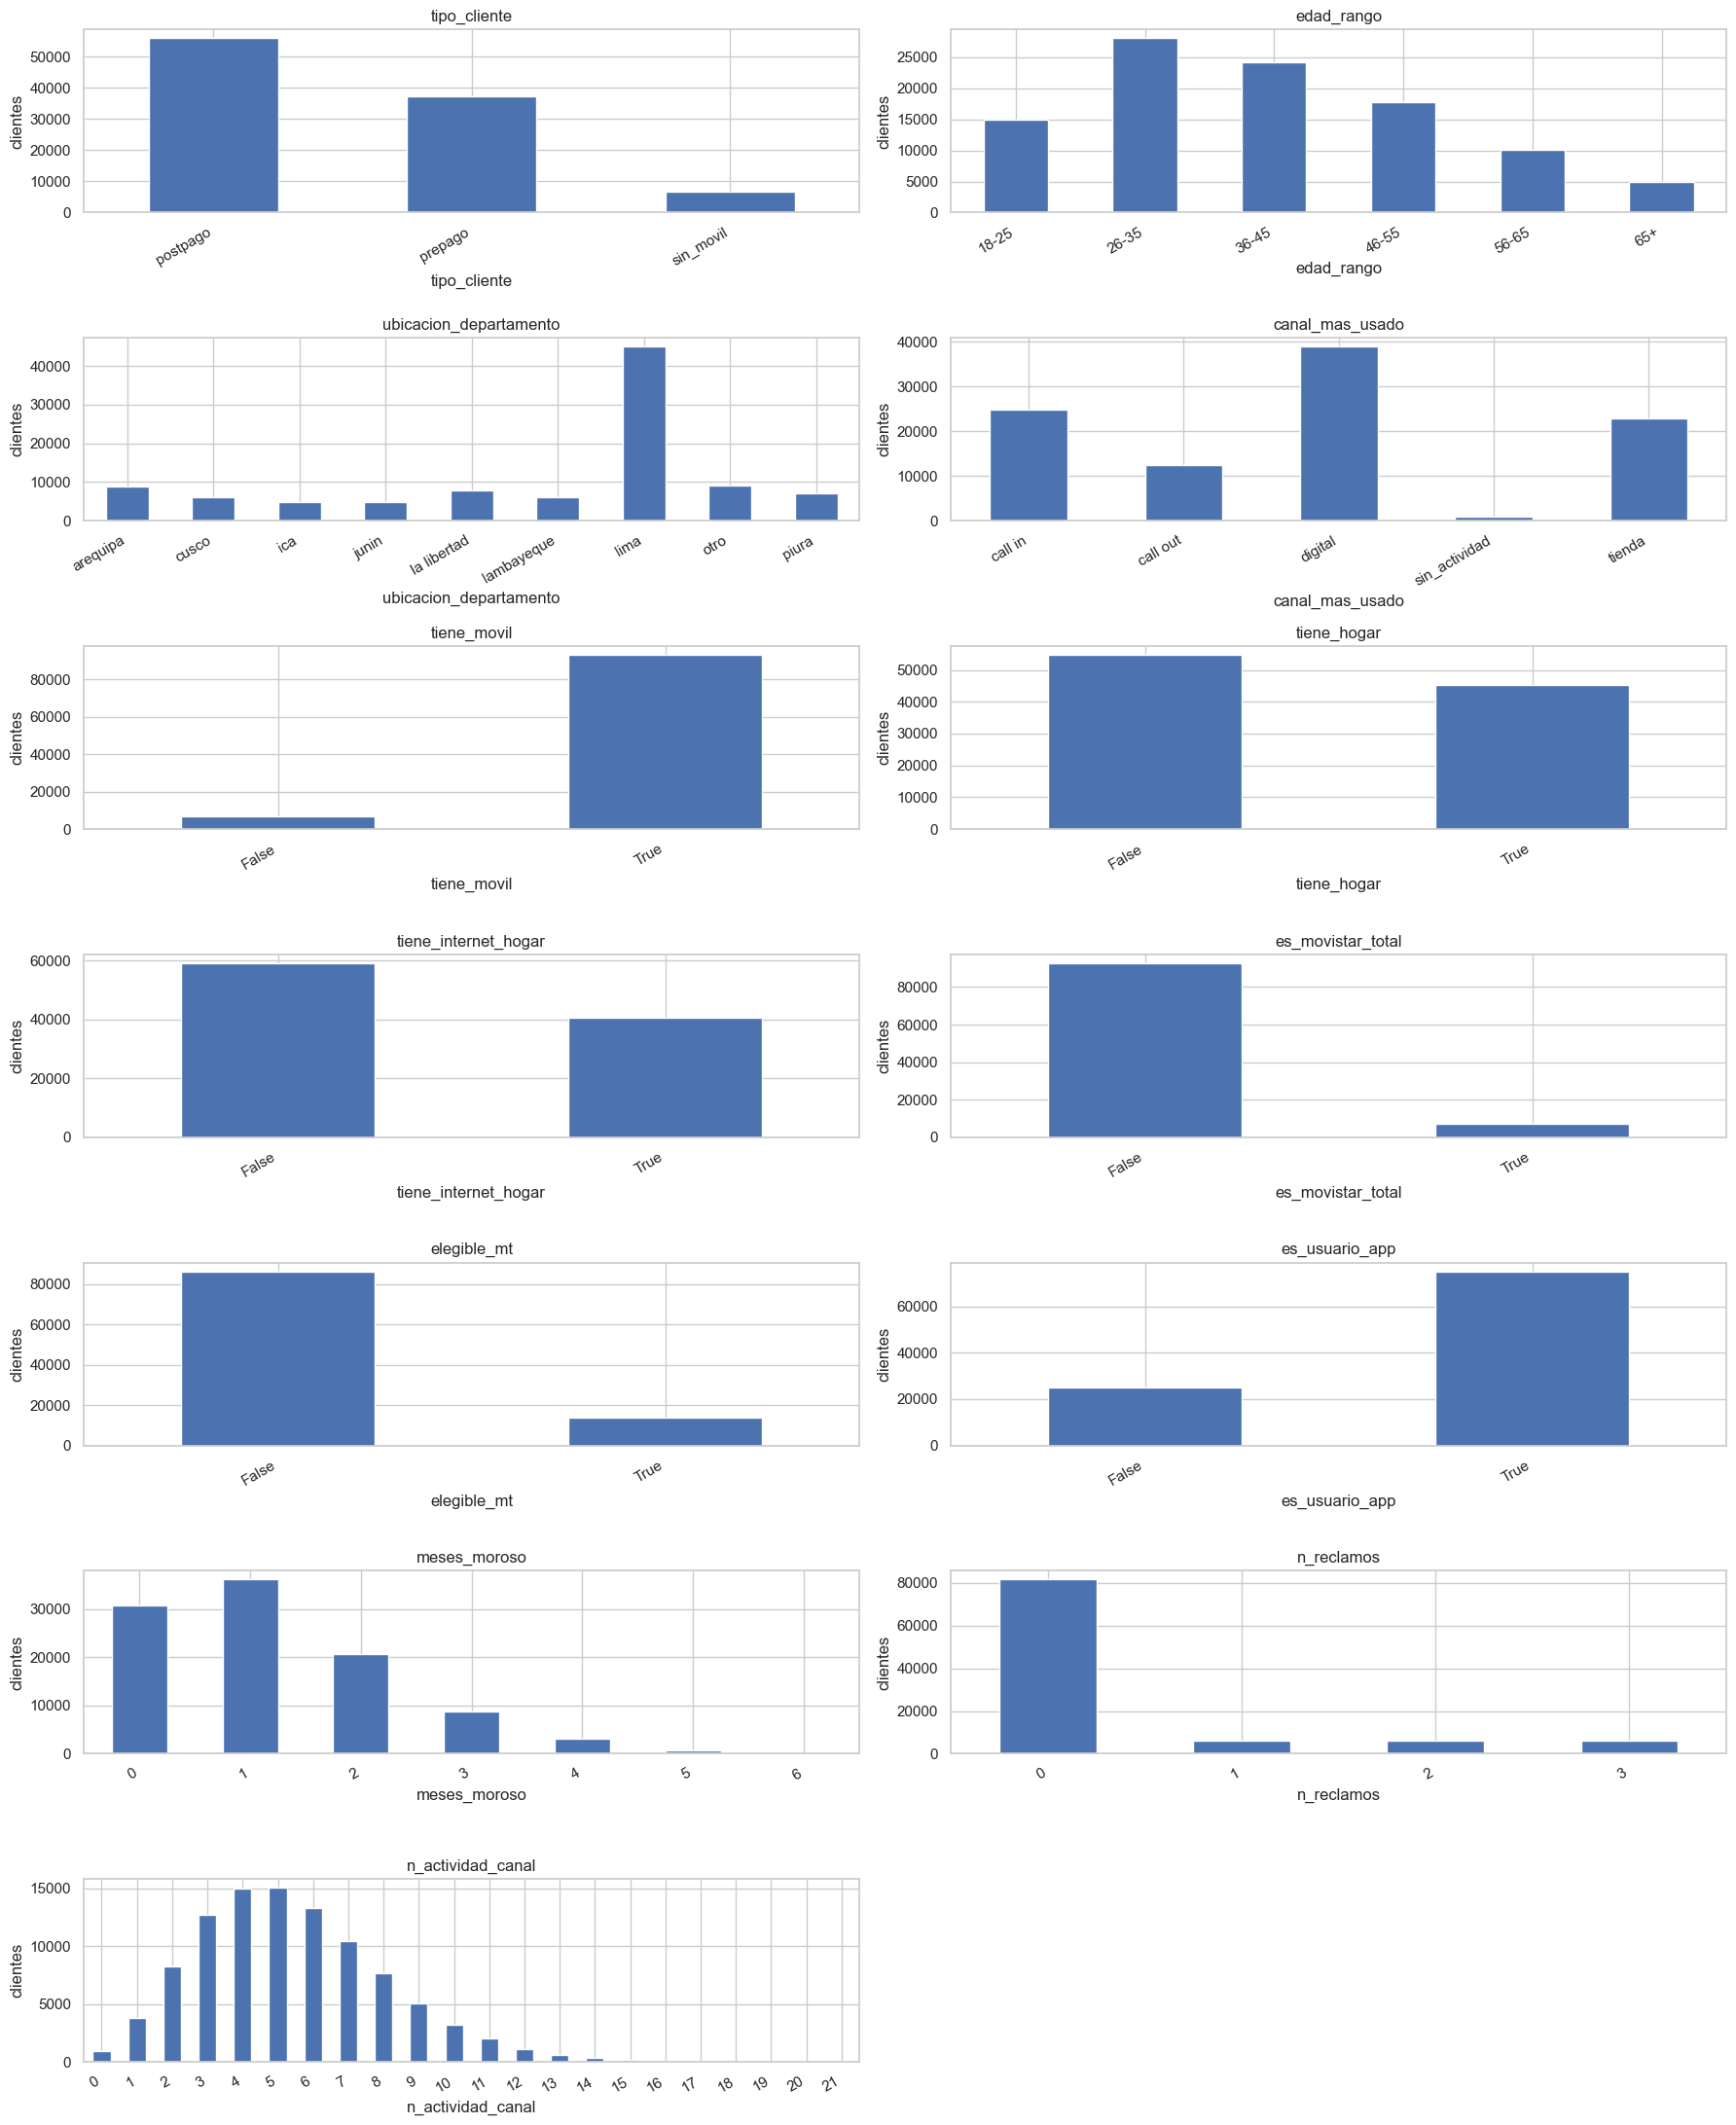

In [16]:
# Graficar distribuciones generales de variables categoricas y ordinales
plt.figure(figsize=(18, 22))
for i, col in enumerate(vars_categoricas, 1):
    plt.subplot(7, 2, i)
    clientes[col].value_counts(dropna=False).sort_index().plot(kind="bar")
    plt.title(col)
    plt.ylabel("clientes")
    plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Hallazgo:** los graficos categoricos muestran la composicion general de la base. Esto ayuda a ver segmentos grandes, segmentos pequenos y categorias estructurales como `sin_movil` o `sin_actividad`.

## 8. Distribucion de variables numericas segun elegibilidad MT

Se revisa visualmente si los clientes elegibles a Movistar Total tienen comportamiento distinto en variables numericas.

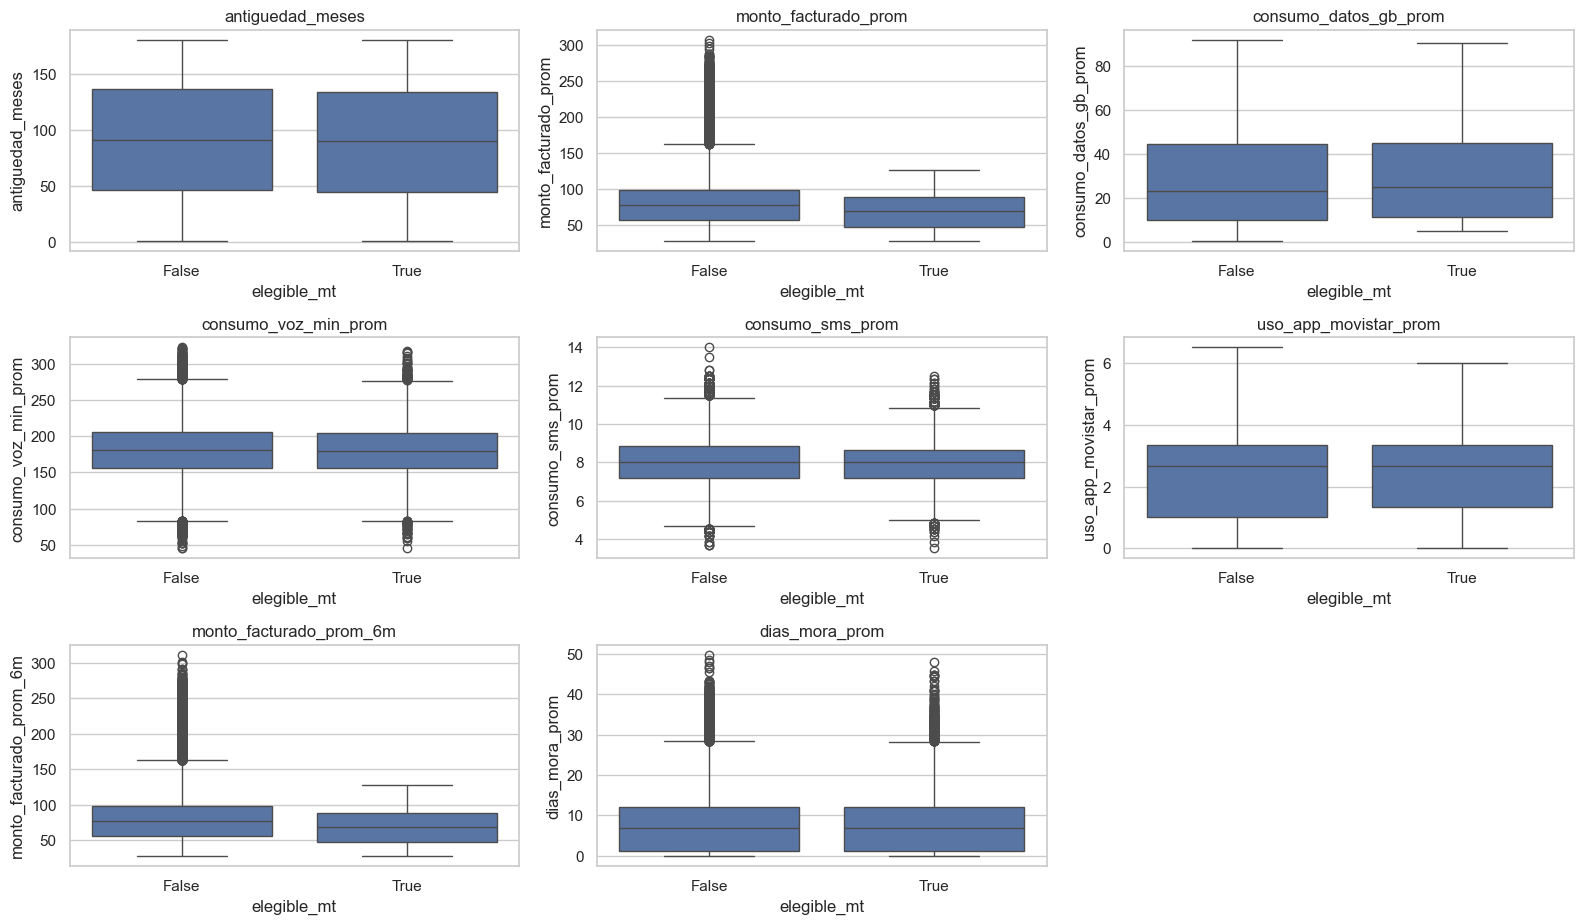

In [17]:
# Boxplots de variables numericas separando por elegibilidad MT
plt.figure(figsize=(16, 12))
for i, col in enumerate(vars_numericas, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=clientes, x="elegible_mt", y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

**Hallazgo:** estos boxplots describen si el segmento elegible MT tiene un perfil distinto en consumo, facturacion, antiguedad o actividad. No miden aceptacion; solo ayudan a caracterizar el universo que luego sera puntuado con el historial de campanias.

## 9. Relaciones generales entre variables numericas

In [18]:
# Calcular correlacion general entre variables numericas
corr_clientes = clientes[vars_numericas].corr()
corr_clientes

,antiguedad_meses,monto_facturado_prom,consumo_datos_gb_prom,consumo_voz_min_prom,consumo_sms_prom,uso_app_movistar_prom,monto_facturado_prom_6m,dias_mora_prom
antiguedad_meses,1.000000,0.001117,-0.000223,0.000800,-0.000608,-0.001289,0.000997,-0.395775
monto_facturado_prom,0.001117,1.000000,0.516555,0.003653,-0.001584,-0.003271,0.999616,0.000182
consumo_datos_gb_prom,-0.000223,0.516555,1.000000,0.006945,-0.004208,-0.005500,0.516236,-0.000241
consumo_voz_min_prom,0.000800,0.003653,0.006945,1.000000,0.006157,0.000336,0.003761,-0.002066
consumo_sms_prom,-0.000608,-0.001584,-0.004208,0.006157,1.000000,0.001447,-0.001638,0.001166
uso_app_movistar_prom,-0.001289,-0.003271,-0.005500,0.000336,0.001447,1.000000,-0.003005,0.003489
monto_facturado_prom_6m,0.000997,0.999616,0.516236,0.003761,-0.001638,-0.003005,1.000000,0.000206
dias_mora_prom,-0.395775,0.000182,-0.000241,-0.002066,0.001166,0.003489,0.000206,1.000000


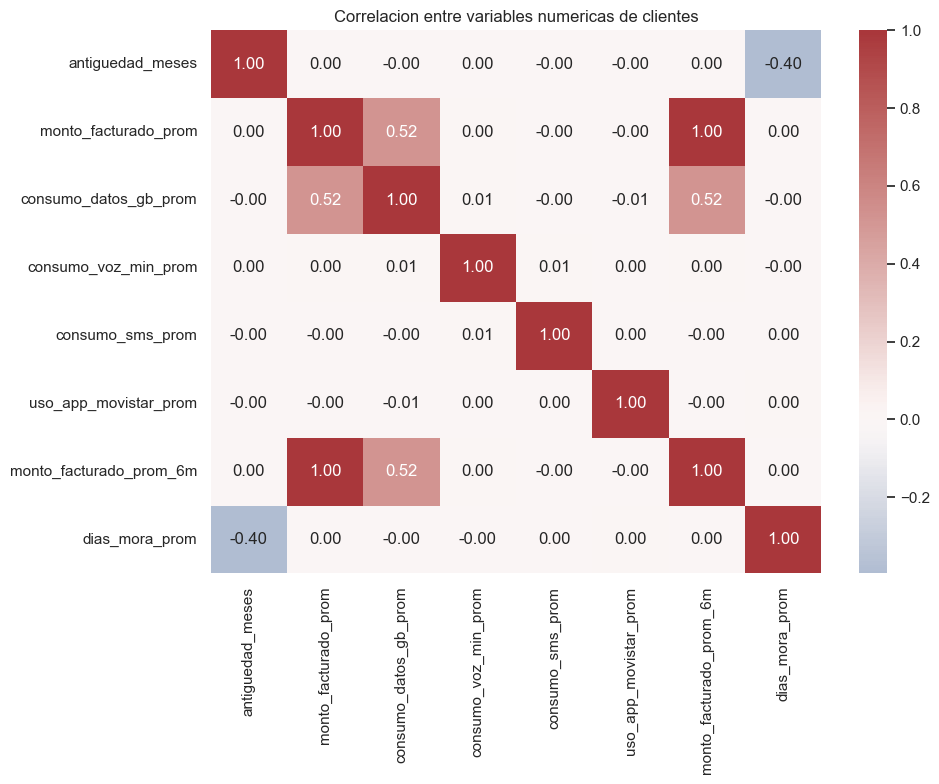

In [19]:
# Graficar heatmap de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(corr_clientes, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlacion entre variables numericas de clientes")
plt.tight_layout()
plt.show()

**Hallazgo:** las correlaciones altas pueden indicar variables redundantes. En este EDA solo se reportan; no se elimina ninguna variable.

## 10. Perfil de clientes elegibles para Movistar Total

`elegible_mt` viene definido en el dataset. Segun el diccionario, identifica al cliente que tiene linea movil, internet hogar, es postpago y todavia no tiene Movistar Total. No es una variable creada en este EDA ni significa que el cliente necesariamente aceptara la oferta.

In [20]:
# Calcular cantidad y porcentaje de clientes elegibles MT
resumen_elegible_mt = clientes["elegible_mt"].value_counts(dropna=False).to_frame("clientes")
resumen_elegible_mt["porcentaje"] = (resumen_elegible_mt["clientes"] / len(clientes) * 100).round(2)
resumen_elegible_mt

,clientes,porcentaje
elegible_mt,,
False,86350,86.35
True,13650,13.65


**Hallazgo negocio:** existen 13,650 clientes elegibles MT, equivalentes al 13.65% de la base. Este es el universo prioritario para el caso MT: permite concentrar el scoring y las acciones comerciales en clientes que cumplen las condiciones del producto, en vez de ofrecerlo masivamente.

In [21]:
# Comparar perfil numerico entre elegibles y no elegibles MT
perfil_mt_numerico = clientes.groupby("elegible_mt")[[
    "monto_facturado_prom",
    "consumo_datos_gb_prom",
    "consumo_voz_min_prom",
    "uso_app_movistar_prom",
    "antiguedad_meses",
    "dias_mora_prom"
]].agg(["mean", "median"])

perfil_mt_numerico

monto_facturado_prom         consumo_datos_gb_prom             \
                            mean  median                  mean     median   
elegible_mt                                                                 
False                  82.997136  77.340             29.503289  23.481667   
True                   69.821590  68.545             30.809496  25.126667   

            consumo_voz_min_prom             uso_app_movistar_prom            \
                            mean      median                  mean    median   
elegible_mt                                                                    
False                 180.994762  180.833333              2.252146  2.666667   
True                  180.115800  179.333333              2.265763  2.666667   

            antiguedad_meses        dias_mora_prom            
                        mean median           mean    median  
elegible_mt                                                   
False              90.558749   91.0       7.980608  6.833333  
True               89.947033   90.0       7.951587  6.833333

**Hallazgo negocio:** comparar elegibles vs no elegibles ayuda a entender si el segmento MT se parece mas a clientes de alto consumo, mayor facturacion, mayor antiguedad o mayor uso digital. Esto orienta el mensaje comercial, pero aun no mide aceptacion.

In [22]:
# Comparar variables categoricas importantes segun elegibilidad MT
pd.crosstab(clientes["tipo_cliente"], clientes["elegible_mt"], normalize="index").round(3) * 100

elegible_mt,False,True
tipo_cliente,,
postpago,75.6,24.4
prepago,100.0,0.0
sin_movil,100.0,0.0


In [23]:
# Edad segun elegibilidad MT
pd.crosstab(clientes["edad_rango"], clientes["elegible_mt"], normalize="index").round(3) * 100

elegible_mt,False,True
edad_rango,,
18-25,86.2,13.8
26-35,86.1,13.9
36-45,86.5,13.5
46-55,86.6,13.4
56-65,86.3,13.7
65+,86.6,13.4


In [24]:
# Canal mas usado segun elegibilidad MT
pd.crosstab(clientes["canal_mas_usado"], clientes["elegible_mt"], normalize="index").round(3) * 100

elegible_mt,False,True
canal_mas_usado,,
call in,86.5,13.5
call out,86.6,13.4
digital,86.3,13.7
sin_actividad,86.8,13.2
tienda,86.1,13.9


**Hallazgo negocio:** estos cruces permiten describir donde se concentra la elegibilidad MT: por tipo de cliente, rango de edad y canal habitual. Sirve para planificar audiencias y canales antes de modelar aceptacion.

## 11. Combinaciones de productos actuales

Se construyen segmentos simples segun productos actuales del cliente: movil, hogar, internet hogar, Movistar Total y elegibilidad MT.

In [25]:
# Crear variables descriptivas de combinacion de productos actuales
clientes["producto_actual"] = "otros"
clientes.loc[(clientes["tiene_movil"] == True) & (clientes["tiene_hogar"] == False), "producto_actual"] = "solo_movil"
clientes.loc[(clientes["tiene_movil"] == False) & (clientes["tiene_hogar"] == True), "producto_actual"] = "solo_hogar"
clientes.loc[(clientes["tiene_movil"] == True) & (clientes["tiene_hogar"] == True), "producto_actual"] = "movil_hogar"
clientes.loc[clientes["es_movistar_total"] == True, "producto_actual"] = "ya_tiene_mt"

clientes["movil_internet_hogar"] = (clientes["tiene_movil"] == True) & (clientes["tiene_internet_hogar"] == True)
clientes["elegible_mt_sin_mt"] = (clientes["elegible_mt"] == True) & (clientes["es_movistar_total"] == False)

In [26]:
# Revisar segmentos de producto actual
clientes["producto_actual"].value_counts(dropna=False).to_frame("clientes").assign(
    porcentaje=lambda x: (x["clientes"] / len(clientes) * 100).round(2)
)

,clientes,porcentaje
producto_actual,,
solo_movil,54758,54.76
movil_hogar,31314,31.31
ya_tiene_mt,7194,7.19
solo_hogar,6734,6.73


In [27]:
# Revisar clientes con movil + internet hogar y elegibles MT sin MT
pd.Series({
    "movil_internet_hogar": clientes["movil_internet_hogar"].sum(),
    "ya_tiene_movistar_total": clientes["es_movistar_total"].sum(),
    "elegible_mt_sin_mt": clientes["elegible_mt_sin_mt"].sum()
}).to_frame("clientes")

,clientes
movil_internet_hogar,34702
ya_tiene_movistar_total,7194
elegible_mt_sin_mt,13650


**Hallazgo negocio:** los clientes con combinaciones de productos como movil + hogar o movil + internet hogar pueden ser candidatos naturales para bundles o Movistar Total. Los elegibles MT que aun no tienen MT representan oportunidad directa de conversion.

## 12. Valor actual del cliente

Se segmenta la facturacion promedio en niveles bajo, medio y alto usando cuantiles. Esto es descriptivo y no implica que mayor valor signifique mayor propension a aceptar ofertas.

In [28]:
# Segmentar facturacion en bajo, medio y alto con cuantiles
clientes["nivel_facturacion"] = pd.qcut(
    clientes["monto_facturado_prom"],
    q=3,
    labels=["bajo", "medio", "alto"]
)

In [29]:
# Comparar grupos de facturacion con consumo, antiguedad, mora, reclamos y engagement
clientes["n_reclamos_num"] = pd.to_numeric(clientes["n_reclamos"].astype(str))
clientes["n_actividad_canal_num"] = pd.to_numeric(clientes["n_actividad_canal"].astype(str))
clientes["meses_moroso_num"] = pd.to_numeric(clientes["meses_moroso"].astype(str))

perfil_valor = clientes.groupby("nivel_facturacion").agg(
    clientes=("cliente_id", "count"),
    facturacion_promedio=("monto_facturado_prom", "mean"),
    consumo_datos_prom=("consumo_datos_gb_prom", "mean"),
    antiguedad_prom=("antiguedad_meses", "mean"),
    dias_mora_prom=("dias_mora_prom", "mean"),
    reclamos_prom=("n_reclamos_num", "mean"),
    actividad_canal_prom=("n_actividad_canal_num", "mean"),
    uso_app_prom=("uso_app_movistar_prom", "mean")
).round(2)

perfil_valor

,clientes,facturacion_promedio,consumo_datos_prom,antiguedad_prom,dias_mora_prom,reclamos_prom,actividad_canal_prom,uso_app_prom
nivel_facturacion,,,,,,,,
bajo,33347,45.74,12.73,90.46,7.97,0.21,5.39,2.26
medio,33324,75.04,31.54,90.53,7.97,0.36,5.39,2.25
alto,33329,122.83,44.79,90.44,7.99,0.53,5.42,2.25


**Hallazgo negocio:** la segmentacion por facturacion permite describir clientes de bajo, medio y alto valor actual. No se debe concluir que los clientes de mayor valor aceptaran mas ofertas; eso se revisara despues con campanias.

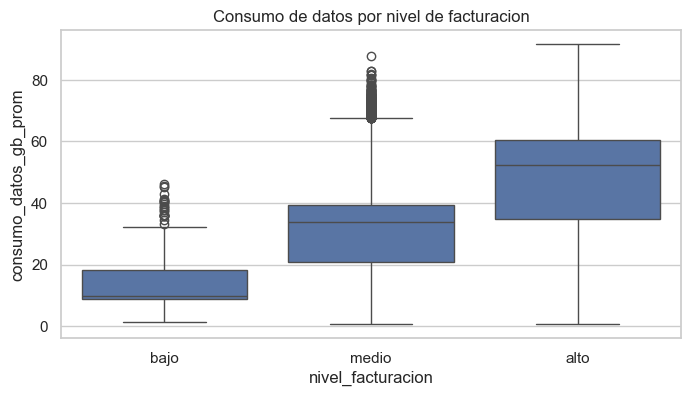

In [30]:
# Visualizar distribucion de consumo por nivel de facturacion
plt.figure(figsize=(8, 4))
sns.boxplot(data=clientes, x="nivel_facturacion", y="consumo_datos_gb_prom")
plt.title("Consumo de datos por nivel de facturacion")
plt.xlabel("nivel_facturacion")
plt.ylabel("consumo_datos_gb_prom")
plt.show()

**Hallazgo negocio:** este grafico ayuda a ver si los clientes de mayor facturacion tambien tienen mayor consumo de datos, lo cual podria orientar ofertas de mayor capacidad o bundles.

## 13. Engagement del cliente

Se revisa el nivel de actividad del cliente en app, sesiones, actividad por canal, canal mas usado y antiguedad.

In [31]:
# Crear segmento simple de engagement usando actividad por canal y uso de app
clientes["nivel_engagement"] = "medio"
clientes.loc[(clientes["n_actividad_canal_num"] <= clientes["n_actividad_canal_num"].quantile(0.25)) & (clientes["uso_app_movistar_prom"] <= clientes["uso_app_movistar_prom"].quantile(0.25)), "nivel_engagement"] = "bajo"
clientes.loc[(clientes["n_actividad_canal_num"] >= clientes["n_actividad_canal_num"].quantile(0.75)) | (clientes["uso_app_movistar_prom"] >= clientes["uso_app_movistar_prom"].quantile(0.75)), "nivel_engagement"] = "alto"

In [32]:
# Revisar perfil de engagement
clientes.groupby("nivel_engagement").agg(
    clientes=("cliente_id", "count"),
    uso_app_prom=("uso_app_movistar_prom", "mean"),
    actividad_canal_prom=("n_actividad_canal_num", "mean"),
    antiguedad_prom=("antiguedad_meses", "mean"),
    facturacion_prom=("monto_facturado_prom", "mean"),
    consumo_datos_prom=("consumo_datos_gb_prom", "mean")
).round(2)

,clientes,uso_app_prom,actividad_canal_prom,antiguedad_prom,facturacion_prom,consumo_datos_prom
nivel_engagement,,,,,,
alto,49048,2.82,6.90,90.29,81.30,29.73
bajo,6449,0.01,2.26,90.22,81.07,29.84
medio,44503,1.96,4.21,90.72,81.10,29.60


In [33]:
# Revisar canal mas usado por nivel de engagement
pd.crosstab(clientes["nivel_engagement"], clientes["canal_mas_usado"], normalize="index").round(3) * 100

canal_mas_usado,call in,call out,digital,sin_actividad,tienda
nivel_engagement,,,,,
alto,22.6,10.7,41.9,0.5,24.4
bajo,32.0,17.5,28.3,3.8,18.5
medio,26.5,13.4,37.2,1.1,21.8


**Hallazgo negocio:** los clientes con engagement alto pueden ser mas faciles de contactar o activar por canales donde ya interactuan. Los de engagement bajo pueden requerir estrategia distinta de contacto o mensajes mas simples.

## 14. Senales de friccion

Se revisan mora, meses moroso y reclamos. El objetivo es identificar clientes con posible friccion comercial o riesgo de mala experiencia.

In [34]:
# Crear indicador simple de friccion alta
clientes["friccion_alta"] = (
    (clientes["dias_mora_prom"] >= clientes["dias_mora_prom"].quantile(0.75)) |
    (clientes["meses_moroso_num"] >= clientes["meses_moroso_num"].quantile(0.75)) |
    (clientes["n_reclamos_num"] > 0)
)

In [35]:
# Perfil segun friccion
clientes.groupby("friccion_alta").agg(
    clientes=("cliente_id", "count"),
    facturacion_prom=("monto_facturado_prom", "mean"),
    consumo_datos_prom=("consumo_datos_gb_prom", "mean"),
    dias_mora_prom=("dias_mora_prom", "mean"),
    meses_moroso_prom=("meses_moroso_num", "mean"),
    reclamos_prom=("n_reclamos_num", "mean"),
    actividad_canal_prom=("n_actividad_canal_num", "mean")
).round(2)

,clientes,facturacion_prom,consumo_datos_prom,dias_mora_prom,meses_moroso_prom,reclamos_prom,actividad_canal_prom
friccion_alta,,,,,,,
False,56948,79.14,27.84,3.71,0.52,0.00,5.39
True,43052,83.92,32.12,13.62,2.08,0.86,5.41


In [36]:
# Clientes de alta facturacion y alta friccion
clientes["alto_valor_alta_friccion"] = (clientes["nivel_facturacion"] == "alto") & (clientes["friccion_alta"] == True)

clientes["alto_valor_alta_friccion"].value_counts(dropna=False).to_frame("clientes").assign(
    porcentaje=lambda x: (x["clientes"] / len(clientes) * 100).round(2)
)

,clientes,porcentaje
alto_valor_alta_friccion,,
False,83948,83.95
True,16052,16.05


**Hallazgo negocio:** los clientes de alta facturacion y alta friccion pueden ser valiosos, pero sensibles. Para ellos, una oferta comercial podria requerir cuidado adicional, beneficios claros o primero resolver la fuente de friccion.

## 15. Oportunidades descriptivas para cross-sell y Movistar Total

In [37]:
# Resumen de oportunidades descriptivas
pd.Series({
    "clientes_solo_movil": ((clientes["tiene_movil"] == True) & (clientes["tiene_hogar"] == False)).sum(),
    "clientes_solo_hogar": ((clientes["tiene_movil"] == False) & (clientes["tiene_hogar"] == True)).sum(),
    "clientes_movil_hogar": ((clientes["tiene_movil"] == True) & (clientes["tiene_hogar"] == True)).sum(),
    "clientes_movil_internet_hogar": clientes["movil_internet_hogar"].sum(),
    "clientes_ya_mt": clientes["es_movistar_total"].sum(),
    "clientes_elegibles_mt_sin_mt": clientes["elegible_mt_sin_mt"].sum(),
    "clientes_alto_valor_alta_friccion": clientes["alto_valor_alta_friccion"].sum(),
    "clientes_engagement_alto": (clientes["nivel_engagement"] == "alto").sum()
}).to_frame("clientes")

,clientes
clientes_solo_movil,54758
clientes_solo_hogar,6734
clientes_movil_hogar,38508
clientes_movil_internet_hogar,34702
clientes_ya_mt,7194
clientes_elegibles_mt_sin_mt,13650
clientes_alto_valor_alta_friccion,16052
clientes_engagement_alto,49048


**Hallazgo negocio:** hay oportunidades distintas segun el punto de partida del cliente: clientes solo movil pueden ser candidatos a hogar o bundle; clientes movil + hogar pueden ser candidatos a MT; clientes de alto engagement pueden ser contactados por canales activos; clientes de alta friccion requieren una propuesta mas cuidadosa.

## 16. Hallazgos de negocio finales del EDA clientes

- Hay 13,650 elegibles MT (13.65%): tienen movil, internet hogar, son postpago y aun no poseen MT. Este es el universo prioritario del caso de uso.
- `elegible_mt` es una regla comercial de elegibilidad, no una probabilidad de compra. La propension se estima despues usando los resultados de campanias.
- No todos los clientes de alta facturacion son automaticamente buenos candidatos: algunos tambien presentan mora o reclamos y requieren una estrategia cuidadosa.
- Los clientes con mayor engagement son mas accionables por canales donde ya interactuan; los clientes `sin_actividad` necesitan una estrategia de contacto distinta.
- Las combinaciones actuales de productos permiten detectar cross-sell: solo movil, solo hogar y movil + hogar tienen necesidades diferentes.
- Para el modelo, las variables de perfil, consumo, antiguedad, friccion y engagement pueden actuar como predictoras, pero su aporte real debe validarse contra aceptacion.